# Descriptors

This notebook focuses on the computation of descriptors, or features, which further **caracterize the local geometry of the surface, capturing patterns** such as linear structures, planar regions, corners, and more complex geometric arrangements. Such features play an essential role in a wide range of downstream tasks, including rendering, surface reconstruction, segmentation, registration, and classification. Many geometric and learning‑based algorithms rely directly on these descriptors to make decisions about similarity, structure, or semantics within the point cloud. Consequently, the accuracy and stability of their computation strongly influence the robustness and effectiveness of subsequent processing steps.

This notebook explores both simple geometric descriptors derived from local neighborhoods and more advanced histogram-based descriptors used for matching and recognition.

In [1]:
# Necessary imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import KDTree

# Load second example pointcloud
data = np.loadtxt("./data/indoor_scene.xyz")
points = data[:, :3]
normals = data[:, 3:6]
# Build KDTree for neighbor search
kdtree = KDTree(points)
# k parameter for neighbor search
k = 12


## 3D & 2D point features

While the computation of normals and curvatures described before tries to approximate the local properties of sampled surfaces in space, there is another type of descriptor, called *point features*, that are designed to capture relevant information for specific tasks. These features often leverage geometric properties but not necessarily focusing on the detailed mathematical descriptions provided by differential geometry. These are specifically used in *3D scene analysis* (mainly indoor, urban and natural scenes) and related machine learning tasks.

A remarkable summary and study of these descriptors can be found in: Weinmann, M., Jutzi, B., Hinz, S., & Mallet, C. (2015). Semantic point cloud interpretation based on optimal neighborhoods, relevant features and efficient classifiers. *ISPRS Journal of Photogrammetry and Remote Sensing*, 105, 286-304.

The following paragraphs cover the features listed in this work, namely *Geometric 3D properties*, *Local 3D shape features*, *Geometric 2D properties*, *Local 2D shape features*, and *Features based on an accumulation map*.


### Geometric 3D properties

Geometric 3D properties are directly based on the coordinates of the points and assume that the $z$-direction represents the vertical direction. Each are considered for a given point $p_i$ and its neighbors $p_j \in N_{k}(p_i)$ (when applicable). A first group of properties is based on local density, while a second group is based on the position and orientation of points according to the vertical axis $z$. These properties are summarized in the table below:

| Feature             | Formula                                                                                | Intuitive meaning                                       |
|:--------------------|:---------------------------------------------------------------------------------------|:--------------------------------------------------------|
| Neighborhood radius | $r_{knn} = \max_{p_j \in N_{k}(p_i)} d(p_i, p_j)$                                      | Radius of the sphere containing the neighbors           |
| Point density       | $D = (k+1)/(\frac{4}{3} \pi r_{knn}^3)$                                                | Local point density                                     |
| Absolute height     | $p_{z,i}$                                                                              | Elevation of the point above the horizontal plane       |
| Height difference   | $\Delta_{z} = \max_{p_j \in N_{k}(p_i)}(p_{z,j}) - \min_{p_j \in N_{k}(p_i)}(p_{z,j})$ | Vertical extent of points in the neighborhood           |
| Height STD          | $\sigma_{z} = \sqrt{\frac{1}{k} \sum_{j=0}^{k-1} (p_{z,j} - \bar{p_{z}})^2}$           | Variation in height within the neighborhood             |
| Verticality         | $V = 1 - \|n_{z}\| $                                                                   | Deviation between the local plane and the vertical axis |


In [2]:
def compute_geometric_descriptor(points, neighbor_finding_function):
    """Compute 3D geometric descriptors: radius, density, height variation, and standard deviation along z."""
    
    dists, inds = neighbor_finding_function(points)
    k = inds.shape[1]  # number of neighbors (including the point itself)
    # Get the radius as the distance to the k-th nearest neighbor (distances are already sorted)
    radius = dists[:, -1]
    # Compute point density as number of neighbors divided by the volume of the sphere
    density = k / (4/3 * np.pi * radius**3)
    # Compute height variation along the z direction
    delta_z = np.ptp(points[inds, 2], axis=1)
    # Compute the standard deviation along the z direction
    std_z = np.std(points[inds, 2], axis=1)
    
    return radius, density, delta_z, std_z


def compute_verticality(normals):
    """Compute verticality descriptor."""
    # 1 - |nz| where nz is the z-component of the normal
    return 1 - np.abs(normals[:, 2])


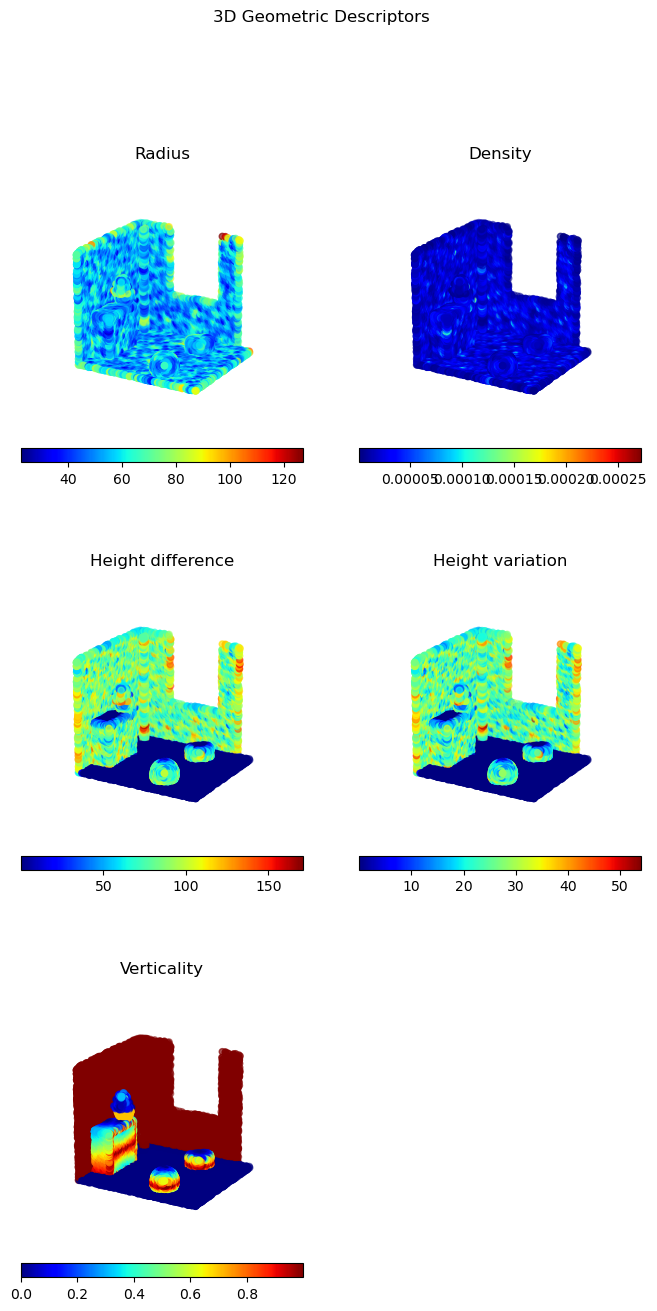

In [3]:
# Compute geometric descriptors
neighbor_finding_function = lambda point: kdtree.query(point, k+1) # +1 because the point itself is included
radius, density, delta_z, std_z = compute_geometric_descriptor(points, neighbor_finding_function)
verticality = compute_verticality(normals)

# Visualize geometric descriptors
descriptors = {
    "Radius": radius,
    "Density": density,
    "Height difference": delta_z,
    "Height variation": std_z,
    "Verticality": verticality
}
fig = plt.figure(figsize=(8, 15))
for i, (name, descriptor) in enumerate(descriptors.items()):
    ax = fig.add_subplot(3, 2, i+1, projection="3d")
    im = ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=descriptor, cmap='jet')
    cbar = fig.colorbar(im, ax=ax, location="bottom", orientation="horizontal", pad=0)
    ax.set_title(name)
    plt.axis("equal")
    ax.view_init(20, 210)
    ax.set_axis_off()
plt.suptitle("3D Geometric Descriptors")
plt.show()


### Local 3D shape features

Local 3D shape features are derived from the eigenvalues $\lambda_1$, $\lambda_2$, and $\lambda_3$ (with $\lambda_1 \geq \lambda_2 \geq \lambda_3 \geq 0$) of the covariance (or inertia) matrix computed from each point's neighborhood. These eigenvalues represent the variance along the principal directions of the neighborhood (this is closely related to *Principal Component Analysis* or PCA). 

Eigen values and their principal directions are often visualized as a 3D ellipsoid, as below. The axes of symmetry of the ellipsoid correspond to the principal directions and their lengths are proportional to the square roots of the eigenvalues (remember that eigenvalues are computed from the covariance matrix). However, note that it is not strictly equivalent to fitting the ellipsoid to the points and its size is arbitrary.

This ellipsoid analogy allows to better understand the geometry around each point and the 3D shape features described below such as linearity, planarity, and scattering.

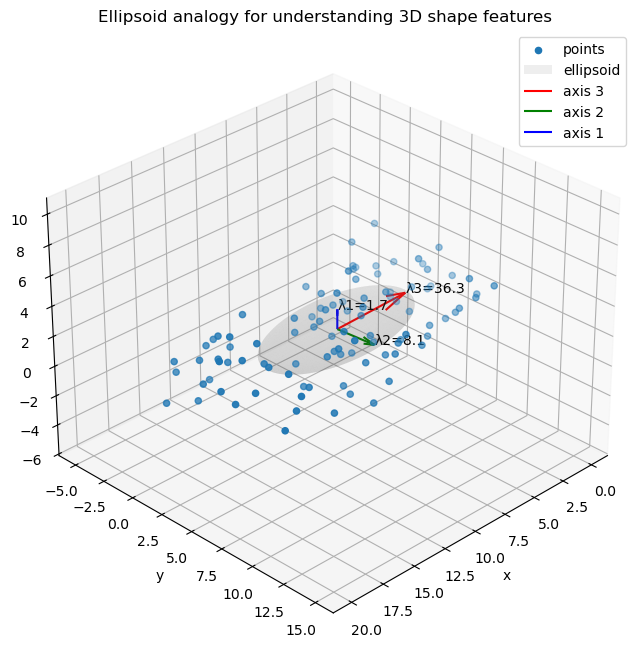

In [4]:
def compute_ellipsoid(points):
    """Compute the ellipsoid from the points."""
    
    # Compute mean and covariance matrix
    mean = np.mean(points, axis=0)
    cov_matrix = np.cov(points, rowvar=False)
    # Eigen decomposition
    # (eigenvalues are in ascending order so not consistent with above notation)
    eigenvalues, eigvectors = np.linalg.eigh(cov_matrix)
    # Create ellipsoid mesh
    u = np.linspace(0, 2 * np.pi, 50)
    v = np.linspace(0, np.pi, 50)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))
    ellipsoid = np.array([x, y, z])
    # Scale by eigenvalues
    for i in range(3):
        ellipsoid[i] *= np.sqrt(eigenvalues[i])
    # Rotate by eigenvectors
    ellipsoid_rotated = np.tensordot(eigvectors, ellipsoid.reshape(3, -1), axes=(1, 0))
    ellipsoid_rotated = ellipsoid_rotated.reshape(3, 50, 50)
    # Translate by mean
    ellipsoid_rotated += mean[:, np.newaxis, np.newaxis]
    
    return mean, eigenvalues, eigvectors, ellipsoid_rotated


# Generate random 3D points
random_points = np.random.random((100, 3))
random_points *= np.array([20, 10, 5]) # adjust the scale
# Compute ellipsoid and principal axes
mean, eigvalues, eigvectors, ellipsoid = compute_ellipsoid(random_points)

# Plot points and ellipsoid
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
# Points
ax.scatter(random_points[:, 0], random_points[:, 1], random_points[:, 2],
           label="points")
# Ellipsoid
ax.plot_surface(ellipsoid[0], ellipsoid[1], ellipsoid[2],
                color="grey", alpha=0.1, label="ellipsoid")
# Principal axes
for i, c in enumerate(["red", "green", "blue"]):
    j = 2 - i # to be consistent with eigenvalue ordering (smallest to largest in eigh)
    axis_vector = np.sqrt(eigvalues[j]) * eigvectors[:, j]
    ax.quiver(mean[0], mean[1], mean[2], axis_vector[0], axis_vector[1], axis_vector[2], 
              color=c, length=1., label=f"axis {j+1}")
    ax.text(mean[0] + axis_vector[0], mean[1] + axis_vector[1], mean[2] + axis_vector[2],
            f"λ{j+1}={eigvalues[j]:.1f}", color="black")
ax.set_title("Ellipsoid analogy for understanding 3D shape features")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.view_init(30, 45)
plt.legend()
plt.axis("equal")
plt.show()


3D shape features directly derive from the "shape" of this ellipsoid. They aim to capture  shape of the local point distribution, as described below:

| Feature             | Formula                                                             | Intuitive meaning                                  |
|:--------------------|:--------------------------------------------------------------------|:---------------------------------------------------|
| Linearity           | $L_{\lambda} = \frac{\lambda_1 - \lambda_2}{\lambda_1}$             | Elongation of the neighborhood (1D)                |
| Planarity           | $P_{\lambda} = \frac{\lambda_2 - \lambda_3}{\lambda_1}$             | Flatness of the neighborhood (2D)                  |
| Scattering          | $S_{\lambda} = \frac{\lambda_3}{\lambda_1}$                         | Degree of volumetric spread (3D)                   |
| Omnivariance        | $O_{\lambda} = (\lambda_1 \lambda_2 \lambda_3)^{\frac{1}{3}}$       | Overall spread in all directions                   |
| Anisotropy          | $A_{\lambda} = \frac{\lambda_1 - \lambda_3}{\lambda_1}$             | Difference between strongest and weakest variation |
| Eigenentropy        | $E_{\lambda} = \sum_{i=1}^{3} - \lambda_i \ln(\lambda_i)$           | Disorder or uniformity of spread                   |
| Sum of eigenvalues  | $\Sigma_{\lambda} = \lambda_1 + \lambda_2 + \lambda_3$              | Overall size of the neighborhood                   |
| Change of curvature | $C_{\lambda} = \frac{\lambda_3}{\lambda_1 + \lambda_2 + \lambda_3}$ | Bending of the surface                             |


In [5]:
def compute_local_3d_features(points, neighbor_finding_function, norm_eigenvalues=False):
    """Compute local 3D features for each point in the point cloud."""
   
    features = {feature: np.zeros(points.shape[0]) for feature in ['linearity', 
        'planarity', 'scattering', 'ominivariance', 'anisotropy', 'eigentropy', 
        'sum_of_eigenvalues', 'change_of_curvature']}

    for i, point in enumerate(points):
        # Find the nearest neighbors
        inds = neighbor_finding_function(point)
        # Get the neighbors
        neighbors = points[inds]
        # Compute the covariance matrix
        cov_matrix = np.cov(neighbors, rowvar=False)
        # Compute the eigenvalues and eigenvectors
        eigenvalues, _ = np.linalg.eigh(cov_matrix)
        # Normalize eigenvalues if required
        if norm_eigenvalues:
            eigenvalues /= np.linalg.norm(eigenvalues)
        # Compute features based on eigenvalues
        features['linearity'][i] = (eigenvalues[2] - eigenvalues[1]) / eigenvalues[2]
        features['planarity'][i] = (eigenvalues[1] - eigenvalues[0]) / eigenvalues[2]
        features['scattering'][i] = eigenvalues[0] / eigenvalues[2]
        features['ominivariance'][i] = (eigenvalues[0] * eigenvalues[1] * eigenvalues[2]) ** (1/3)
        features['anisotropy'][i] = (eigenvalues[2] - eigenvalues[0]) / eigenvalues[2]
        features['eigentropy'][i] = -np.sum((eigenvalues) * np.log(eigenvalues) + 1e-10)
        features['sum_of_eigenvalues'][i] = np.sum(eigenvalues)
        features['change_of_curvature'][i] = eigenvalues[0] / np.sum(eigenvalues)

    return features


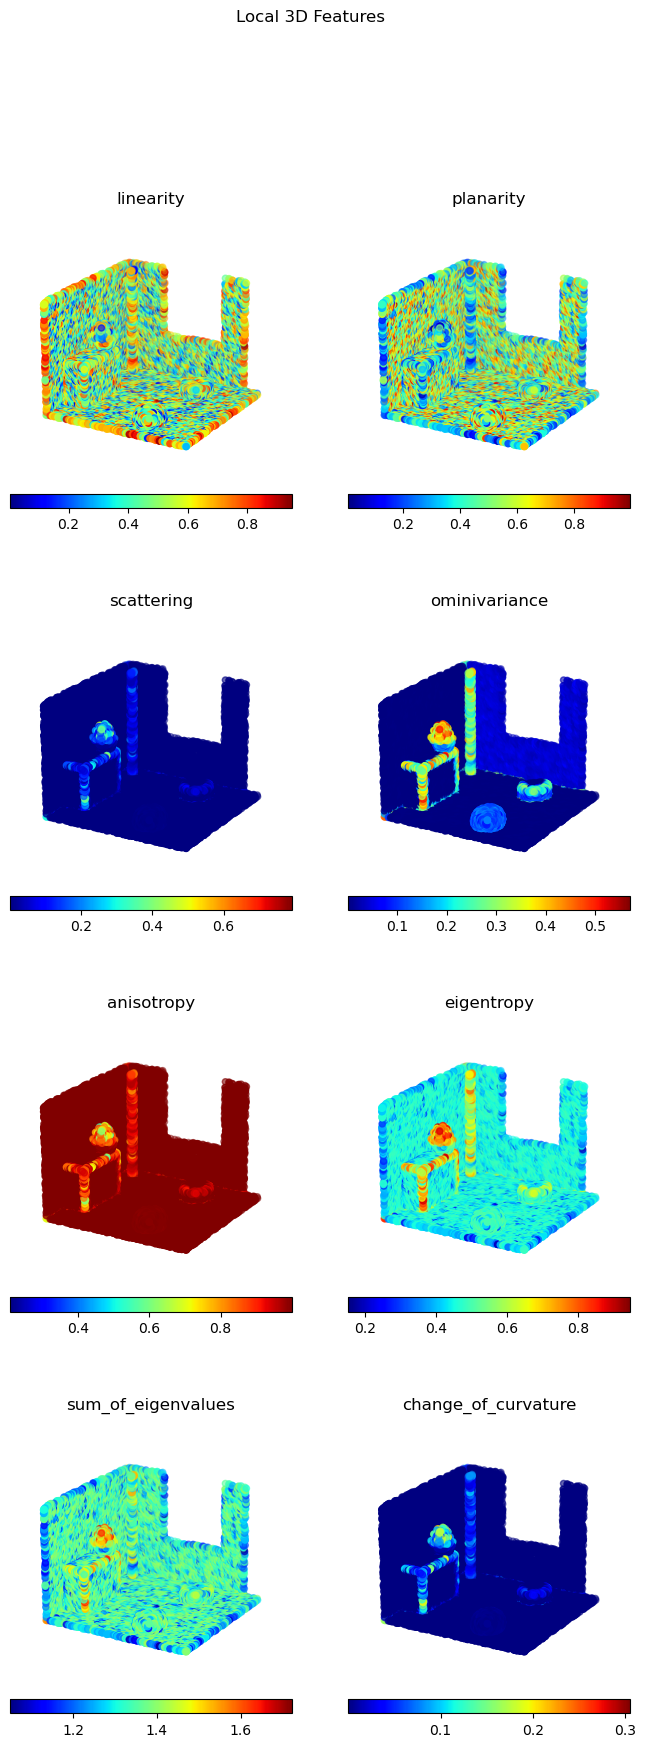

In [6]:
# Compute local 3D features
neighbor_finding_function = lambda point: kdtree.query(point, k+1)[1] # +1 because the point itself is included
local_3d_features = compute_local_3d_features(points, neighbor_finding_function, norm_eigenvalues=True)
# Visualize local 3D features
fig = plt.figure(figsize=(8, 20))
for i, (name, feature) in enumerate(local_3d_features.items()):
    ax = fig.add_subplot(4, 2, i+1, projection="3d")
    im = ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=feature, cmap='jet')
    cbar = fig.colorbar(im, ax=ax, location="bottom", orientation="horizontal", pad=0)
    ax.set_title(name)
    ax.view_init(20, 210)
    ax.set_axis_off()
plt.suptitle("Local 3D Features")
plt.show()


### Geometric 2D properties

Geometric 2D properties are directly based on the $x$ and $y$ coordinates of the points, assuming that the $z$-direction represents the vertical direction. These properties are similar to 3D properties. Although "2D", they are considered for a given point $p_i$ and its neighbors $p_j \in N_{k}(p_i)$ in 3D. In other words, **the closest neighbors considered here are still based on 3D distances**.

| Feature                | Formula                                 | Intuitive meaning                      |
|:-----------------------|:----------------------------------------|:---------------------------------------|
| 2D neighborhood radius | $r_{kNN,2D} = \max_{p_j \in N_{k}(p_i)} \|\| (p_{x,i}, p_{y,i}) - (p_{x,j}, p_{y,j}) \|\|_{2}$ | Size of the circular neighborhood in the $(Oxy)$-plane |
| 2D point density       | $D_{2D} = (k+1)/(\pi r_{kNN,2D}^2)$     | Density of points in the $(Oxy)$-plane |


In [7]:
def compute_2d_descriptors(points, neighbor_finding_function):
    """Compute local 2D features for each point in the point cloud."""
   
    features = {feature: np.zeros(points.shape[0]) for feature in ["radius_2d", "density_2d"]}
    
    for i, point in enumerate(points):
        # Find the nearest neighbors (in 3D)
        inds = neighbor_finding_function(point)
        k = len(inds)  # number of neighbors (including the point itself)
        # Get the neighbors x and y coordinates
        neighbors_xy = points[inds, :2]
        # Compute distances in 2D
        dists = np.linalg.norm(neighbors_xy - point[:2], axis=1)
        # Get the radius as the distance to the farthest nearest neighbor
        radius = np.max(dists)
        features['radius_2d'][i] = radius
        # Compute 2D density
        area = np.pi * (radius ** 2)
        #area = np.pi * (np.max(np.linalg.norm(neighbors_xy - point[:2], axis=1)) ** 2)
        features['density_2d'][i] = k / area

    return features


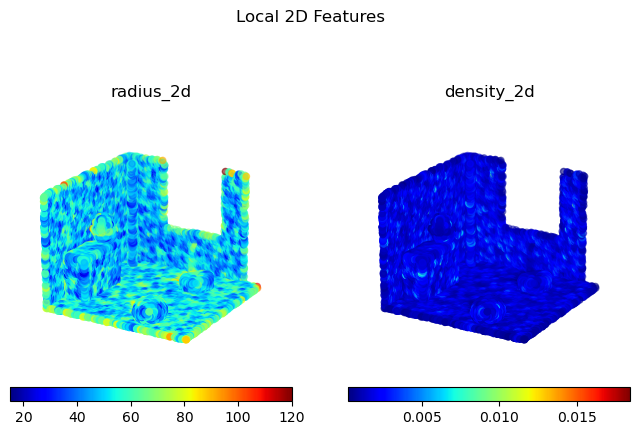

In [8]:
# Compute local 2D features
neighbor_finding_function = lambda point: kdtree.query(point, k+1)[1] # +1 because the point itself is included
local_2d_features = compute_2d_descriptors(points, neighbor_finding_function)

# Visualize local 2D features
fig = plt.figure(figsize=(8, 5))
for i, (name, feature) in enumerate(local_2d_features.items()):
    ax = fig.add_subplot(1, 2, i+1, projection="3d")
    im = ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=feature, cmap='jet')
    cbar = fig.colorbar(im, ax=ax, location="bottom", orientation="horizontal", pad=0)
    #cbar.set_label(name)
    ax.set_title(name)
    ax.view_init(20, 210)
    ax.set_axis_off()
plt.suptitle("Local 2D Features")
plt.show()


### Local 2D shape features

Similarly as for local 3D shape features, local 2D shape features are derived from the eigenvalues of the covariance (or inertia) matrix, only this time in 2D, that is only considering $x$ and $y$-coordinates. These eigenvalues are noted $\lambda_1$ and $\lambda_2$ (with $\lambda_1 \geq \lambda_2 \geq 0$) and the the 2D covariance (or inertia) matrix is computed from each point's 3D neighborhood but agin only considering $x$ and $y$-coordinates. These eigen values and their principal directions could be visualized as a 2D ellipsoid. Again, note that **the neighbors considered here for the computation of the covariance matrix are based on 3D distances**.

| Feature                    | Formula                                                   | Intuitive meaning                                     |
|:---------------------------|:----------------------------------------------------------|:------------------------------------------------------|
| Sum of Eigenvalues in 2D   | $\Sigma_{\lambda, 2D} = \lambda_{1, 2D} + \lambda_{2,2D}$ | Overall size of the neighborhood in the $(Oxy)$-plane |
| Ratio of Eigenvalues in 2D | $R_{\lambda, 2D} = \lambda_{2,\text{2D}} / \lambda_{1,\text{2D}}$ | Elongation in $(Oxy)$-plane |


In [9]:
def compute_local_2d_features(points, neighbor_finding_function, norm_eigenvalues=False):
    """Compute local 2D features for each point in the point cloud."""
   
    features = {feature: np.zeros(points.shape[0]) for feature in ["sum_of_eigenvalues_2d",
        "ratio_eigenvalues_2d"]}
    
    for i, point in enumerate(points):
        # Find the nearest neighbors (in 3D)
        inds = neighbor_finding_function(point)
        # Get the neighbors x and y coordinates
        neighbors_xy = points[inds, :2]
        # Compute 2D the covariance matrix
        cov_matrix = np.cov(neighbors_xy, rowvar=False)
        # Compute the eigenvalues and eigenvectors
        eigenvalues, _ = np.linalg.eigh(cov_matrix)
        # Normalize eigenvalues if required
        if norm_eigenvalues:
            eigenvalues /= np.linalg.norm(eigenvalues)
        # Compute features based on eigenvalues
        features['sum_of_eigenvalues_2d'][i] = np.sum(eigenvalues)
        features['ratio_eigenvalues_2d'][i] = eigenvalues[0] / (eigenvalues[1] + 1e-10)

    return features


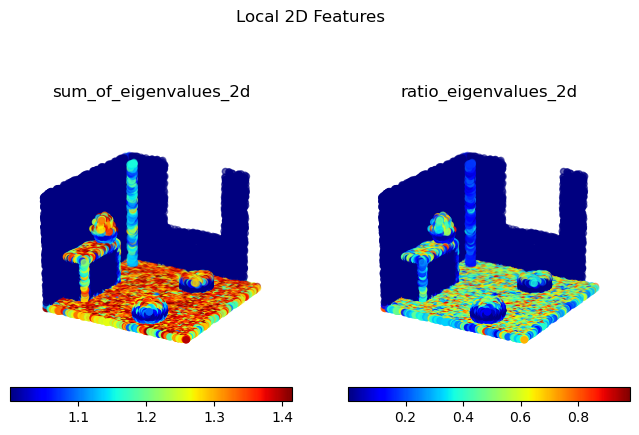

In [10]:
# Compute local 2D features
neighbor_finding_function = lambda point: kdtree.query(point, k+1)[1] # +1 because the point itself is included
local_2d_features = compute_local_2d_features(points, neighbor_finding_function, norm_eigenvalues=True)

# Visualize local 2D features
fig = plt.figure(figsize=(8, 5))
for i, (name, feature) in enumerate(local_2d_features.items()):
    ax = fig.add_subplot(1, 2, i+1, projection="3d")
    im = ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=feature, cmap='jet')
    cbar = fig.colorbar(im, ax=ax, location="bottom", orientation="horizontal", pad=0)
    ax.set_title(name)
    ax.view_init(20, 210)
    ax.set_axis_off()
plt.suptitle("Local 2D Features")
plt.show()


### Accumulation map-based features

Accumulation map-based features are based on spatial binning, which could be seen as another way to compute neighborhoods by discretizing the 2D horizontal projection plane and deriving a 2D accumulation map with quadratic bins. Features capturing local spatial and vertical variability are then computed for each bin. These include the **number of points** falling into the bin, the **maximum height difference** within the bin, and the **standard deviation of height values**​ (formulas are similar than for Geometric 3D properties). These features are particularly useful for detecting vertical structures and assessing local elevation variation in urban scenes.


## Wrapping up

You should now have a better grasp of how to compute descriptors, also called features, that enrich each point with higher‑level geometric information. These descriptors go beyond normals and curvatures, enabling algorithms to better analyze, classify, and interpret complex 3D structures.

**Local geometric descriptors** derived from eigenvalue analysis (such as *linearity*, *planarity*, *sphericity*, and *omnivariance*) capture the shape characteristics of the immediate neighborhood around each point. They are especially useful for segmentation, semantic labeling, and identifying structural patterns within the data. Histogram‑based descriptors such as FPFH, SHOT, or Spin Images encode the spatial arrangement of normals or geometric relationships around a point. These play a key role in tasks like global registration, correspondence search, and object recognition, where robust and discriminative representations are required. As you have seen, the quality and reliability of descriptor computation depend strongly on neighborhood selection, sampling density, and normal estimation.